In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
df=pd.read_csv('C:/ML Practical/medical_insurance.csv')
df.head()
df.shape
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
df.dropna(inplace=True)

In [5]:
df.fillna(method='ffill', inplace=True)

C:\Users\Tanmay varma\AppData\Local\Temp\ipykernel_1548\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [6]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [7]:
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
2767   47  female  45.320         1     no  southeast   8569.86180
2768   21  female  34.600         0     no  southwest   2020.17700
2769   19    male  26.030         1    yes  northwest  16450.89470
2770   23    male  18.715         0     no  northwest  21595.38229
2771   54    male  31.600         0     no  southwest   9850.43200

[2772 rows x 7 columns]


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load data
df = pd.read_csv('medical_insurance.csv')

X = df[['age', 'bmi', 'children', 'smoker', 'sex', 'region']]
y = df['charges']

# 2. Preprocessing pipeline
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['smoker', 'sex', 'region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', PolynomialFeatures(degree=2, include_bias=False), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# 3. Model Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 4. Train & Evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² Score: 0.7445
RMSE: 6262.24


RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

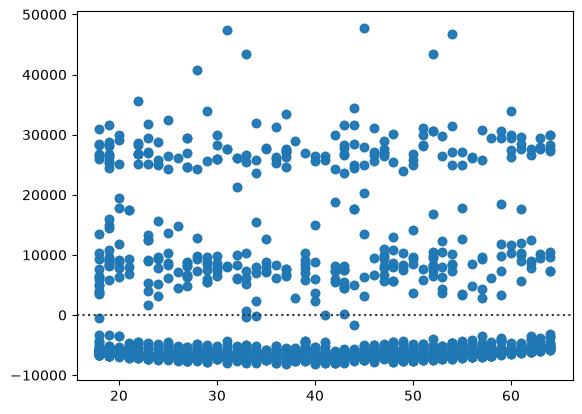

In [13]:
# 1. Residual Plot (U-shape / Curve = Non-Linear | Random scatter = Linear)
sns.residplot(data=df, x='age', y='charges', lowess=True, line_kws={'color': 'red'})
plt.title("Residual Plot")
plt.show()

# 2. LOWESS Scatter Plot (Bended line = Non-Linear)
sns.regplot(data=df, x='age', y='charges', lowess=True, line_kws={'color': 'red'})
plt.title("Scatter with Smooth Fit")
plt.show()